In [1]:
# Cell 0 — Setup
!pip -q install scipy seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")
np.set_printoptions(suppress=True, precision=4)

print("✅ Ready — NumPy:", np.__version__)
import scipy
print("✅ SciPy:", scipy.__version__)


✅ Ready — NumPy: 2.0.2
✅ SciPy: 1.16.1


In [2]:
# Cell 1 — Exercise 1: SciPy version
import scipy
print("SciPy version:", scipy.__version__)


SciPy version: 1.16.1


In [3]:
# Cell 2 — Exercise 2: mean, median, variance, std with SciPy
from scipy import stats

data = [12, 15, 13, 12, 18, 20, 22, 21]

mean_val   = stats.tmean(data)
median_val = np.median(data)          # SciPy uses numpy for median
var_val    = stats.tvar(data, ddof=0) # population variance
std_val    = stats.tstd(data, ddof=0) # population std

print(f"Mean: {mean_val:.2f}")
print(f"Median: {median_val:.2f}")
print(f"Variance (pop): {var_val:.2f}")
print(f"Std Dev (pop): {std_val:.2f}")


Mean: 16.62
Median: 16.50
Variance (pop): 14.98
Std Dev (pop): 3.87


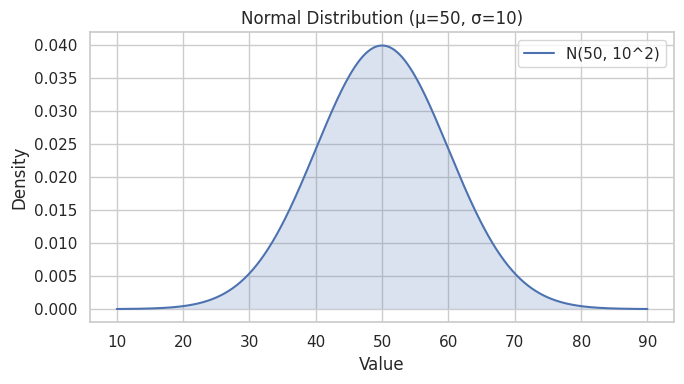

In [4]:
# Cell 3 — Exercise 3: generate and plot a normal distribution
from scipy.stats import norm

mu, sigma = 50, 10
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
y = norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(7,4))
plt.plot(x, y, label=f"N({mu}, {sigma}^2)")
plt.fill_between(x, y, alpha=0.2)
plt.title("Normal Distribution (μ=50, σ=10)")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
# Cell 4 — Exercise 4: independent two-sample t-test
np.random.seed(0)  # reproducibility for this exercise only
data1 = np.random.normal(50, 10, 100)
data2 = np.random.normal(60, 10, 100)

t_stat, p_val = stats.ttest_ind(data1, data2, equal_var=False)  # Welch's t-test
print(f"T-statistic: {t_stat:.3f} | P-value: {p_val:.3e}")

if p_val < 0.05:
    print("➡️ Reject H0: the means differ significantly.")
else:
    print("➡️ Fail to reject H0: no significant difference in means.")


T-statistic: -7.041 | P-value: 3.065e-11
➡️ Reject H0: the means differ significantly.


Slope: 1828.77 (currency per m²)
Intercept: 64383.56
R²: 0.9884
Predicted price for 90 m²: 228972.60

Interpretation:
For each additional square meter, the model increases the price by about 1829 currency units on average.


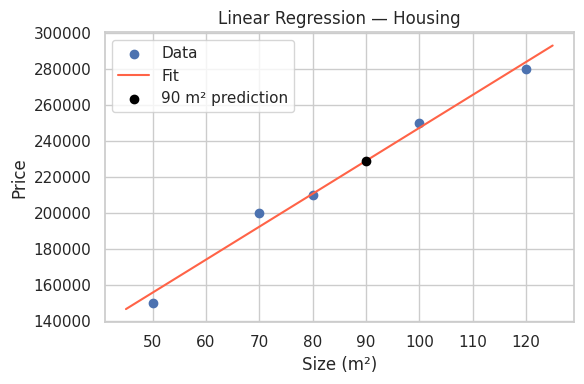

In [6]:
# Cell 5 — Exercise 5: Linear regression on housing size/price
from scipy.stats import linregress

house_sizes  = np.array([50, 70, 80, 100, 120], dtype=float)
house_prices = np.array([150_000, 200_000, 210_000, 250_000, 280_000], dtype=float)

res = linregress(house_sizes, house_prices)

print(f"Slope: {res.slope:.2f} (currency per m²)")
print(f"Intercept: {res.intercept:.2f}")
print(f"R²: {res.rvalue**2:.4f}")
pred_90 = res.slope*90 + res.intercept
print(f"Predicted price for 90 m²: {pred_90:.2f}")

# Interpretation of slope:
print("\nInterpretation:")
print("For each additional square meter, the model increases the price by about "
      f"{res.slope:.0f} currency units on average.")

# Quick plot
plt.figure(figsize=(6,4))
plt.scatter(house_sizes, house_prices, label="Data")
x_line = np.linspace(45, 125, 100)
plt.plot(x_line, res.slope*x_line + res.intercept, color="tomato", label="Fit")
plt.scatter([90], [pred_90], color="black", zorder=5, label="90 m² prediction")
plt.xlabel("Size (m²)"); plt.ylabel("Price")
plt.title("Linear Regression — Housing")
plt.legend(); plt.tight_layout(); plt.show()


In [7]:
# Cell 6 — Exercise 6: ANOVA on three fertilizers
fertilizer_1 = [5, 6, 7, 6, 5]
fertilizer_2 = [7, 8, 7, 9, 8]
fertilizer_3 = [4, 5, 4, 3, 4]

F, p = stats.f_oneway(fertilizer_1, fertilizer_2, fertilizer_3)
print(f"F-value: {F:.3f} | P-value: {p:.3e}")

if p < 0.05:
    print("➡️ Reject H0: at least one fertilizer has a different mean effect.")
else:
    print("➡️ Fail to reject H0: no evidence of different mean effects.")

print("\nIf P-value > 0.05, we would conclude there is no statistically significant")
print("difference among the mean plant growths for the fertilizers (at α=0.05).")


F-value: 28.526 | P-value: 2.754e-05
➡️ Reject H0: at least one fertilizer has a different mean effect.

If P-value > 0.05, we would conclude there is no statistically significant
difference among the mean plant growths for the fertilizers (at α=0.05).


P(X=5 heads in 10 flips) = 0.2461


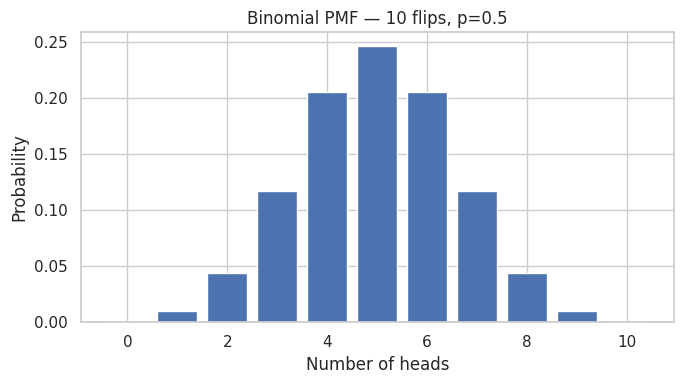

In [8]:
# Cell 7 — Optional: Binomial distribution — P(exactly 5 heads in 10 flips)
from scipy.stats import binom

n, p_head, k = 10, 0.5, 5
prob_5 = binom.pmf(k, n, p_head)
print(f"P(X=5 heads in 10 flips) = {prob_5:.4f}")

# Show distribution
k_vals = np.arange(0, n+1)
plt.figure(figsize=(7,4))
plt.bar(k_vals, binom.pmf(k_vals, n, p_head))
plt.title("Binomial PMF — 10 flips, p=0.5")
plt.xlabel("Number of heads"); plt.ylabel("Probability")
plt.tight_layout(); plt.show()


In [9]:
# Cell 8 — Optional: Pearson & Spearman correlations
df = pd.DataFrame({'age': [23, 25, 30, 35, 40],
                   'income': [35000, 40000, 50000, 60000, 70000]})

pearson_r, pearson_p = stats.pearsonr(df['age'], df['income'])
spearman_r, spearman_p = stats.spearmanr(df['age'], df['income'])

print(f"Pearson r={pearson_r:.3f}, p={pearson_p:.3e}")
print(f"Spearman ρ={spearman_r:.3f}, p={spearman_p:.3e}")


Pearson r=1.000, p=6.528e-06
Spearman ρ=1.000, p=1.404e-24
